## 1. Install & Import Libraries

In [1]:
# Install scikit-image for SSIM/PSNR metrics
!pip install scikit-image -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


## 2. Load & Preprocess CIFAR-10

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Class names for display
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f'Train set: {x_train.shape}  |  Test set: {x_test.shape}')
print(f'Image shape: {x_train.shape[1:]}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train set: (50000, 32, 32, 3)  |  Test set: (10000, 32, 32, 3)
Image shape: (32, 32, 3)


## 3. Add Gaussian Noise

In [3]:
def add_noise(images, noise_factor=0.3):
    """Add Gaussian noise and clip to [0, 1]."""
    noisy = images + noise_factor * np.random.randn(*images.shape)
    return np.clip(noisy, 0.0, 1.0)

NOISE_FACTOR = 0.3   # Try 0.1 (mild) to 0.5 (heavy)

x_train_noisy = add_noise(x_train, NOISE_FACTOR)
x_test_noisy  = add_noise(x_test,  NOISE_FACTOR)

print(f'Noise factor: {NOISE_FACTOR}')
print(f'Noisy pixel range: [{x_train_noisy.min():.3f}, {x_train_noisy.max():.3f}]')

Noise factor: 0.3
Noisy pixel range: [0.000, 1.000]


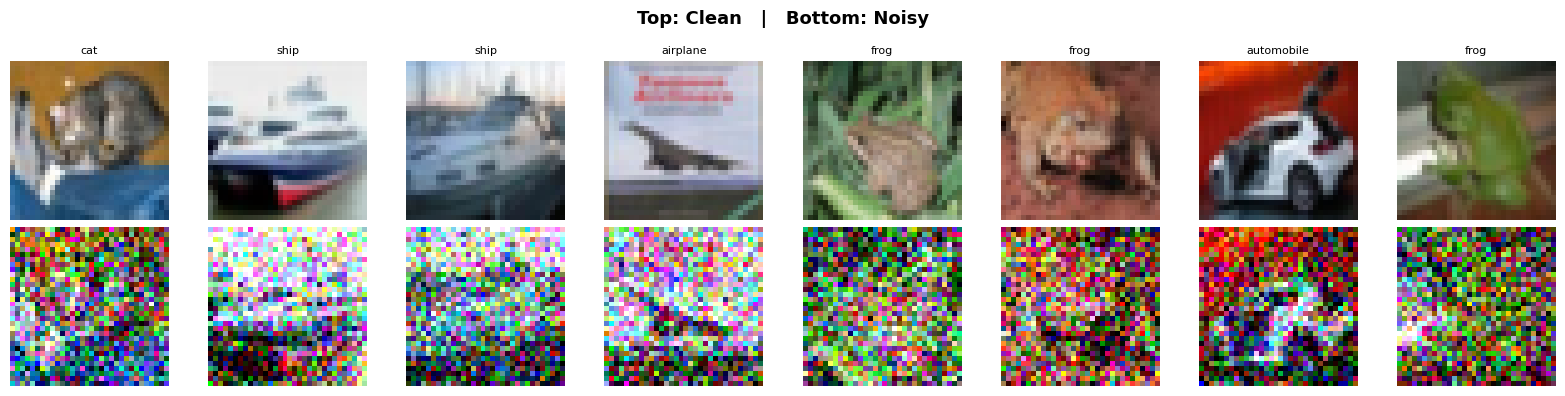

In [4]:
# Visualise clean vs noisy
n = 8
fig, axes = plt.subplots(2, n, figsize=(16, 4))
fig.suptitle('Top: Clean   |   Bottom: Noisy', fontsize=13, fontweight='bold')

for i in range(n):
    axes[0, i].imshow(x_test[i])
    axes[0, i].set_title(class_names[y_test[i][0]], fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_test_noisy[i])
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 4. Build the Convolutional Autoencoder

```
Input (32×32×3)
   ↓ Encoder
Conv → Conv → MaxPool → Conv → Conv → MaxPool
   ↓ Bottleneck (8×8×128)
   ↑ Decoder
UpSampling → Conv → Conv → UpSampling → Conv → Conv
   ↑ Output (32×32×3)
```

In [5]:
def build_autoencoder(input_shape=(32, 32, 3)):
    inputs = keras.Input(shape=input_shape, name='noisy_input')

    # ── Encoder ──────────────────────────────────────────────────
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)           # 16×16×64
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)           # 8×8×128  ← bottleneck

    # ── Decoder ──────────────────────────────────────────────────
    x = layers.UpSampling2D(2)(x)                           # 16×16×128
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(64,  3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)                           # 32×32×64
    x = layers.Conv2D(64,  3, activation='relu', padding='same')(x)
    outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same', name='clean_output')(x)

    model = keras.Model(inputs, outputs, name='Denoising_Autoencoder')
    return model

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_output (Conv2D)           │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,195 (1.98 MB)

 Trainable params: 520,195 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile & Train

In [6]:
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',          # Mean Squared Error between denoised & clean
    metrics=['mae']
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint('best_autoencoder.h5', monitor='val_loss', save_best_only=True, verbose=0)
]

print('Starting training...')
history = autoencoder.fit(
    x_train_noisy, x_train,          # noisy → clean
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=callbacks,
    verbose=1
)

Starting training...
Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0201 - mae: 0.1040

391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - loss: 0.0119 - mae: 0.0799 - val_loss: 0.0078 - val_mae: 0.0669 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0073 - mae: 0.0640

391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - loss: 0.0069 - mae: 0.0625 - val_loss: 0.0064 - val_mae: 0.0603 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0064 - mae: 0.0602

391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0064 - mae: 0.0601 - val_loss: 0.0064 - val_mae: 0.0602 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0062 - mae: 0.0593

391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - loss: 0.0062 - mae: 0.0590 - val_loss: 0.0060 - val_mae: 0.0582 - learning_rate: 0.0010
Epoch 5/50
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0060 - mae: 0.0583

...

391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.9531e-06
Epoch 41/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.9531e-06
Epoch 42/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0052 - mae: 0.0539
Epoch 42: ReduceLROnPlateau reducing learning rate to 1e-06.
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.9531e-06
Epoch 43/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.0000e-06
Epoch 44/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0052 - mae: 0.0538

391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.0000e-06
Epoch 45/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0052 - mae: 0.0538

391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.0000e-06
Epoch 46/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0052 - mae: 0.0539

391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.0000e-06
Epoch 47/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.0000e-06
Epoch 48/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0052 - mae: 0.0538

391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.0000e-06
Epoch 49/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.0000e-06
Epoch 50/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0052 - mae: 0.0539 - val_loss: 0.0054 - val_mae: 0.0546 - learning_rate: 1.0000e-06


## 6. Training Curves

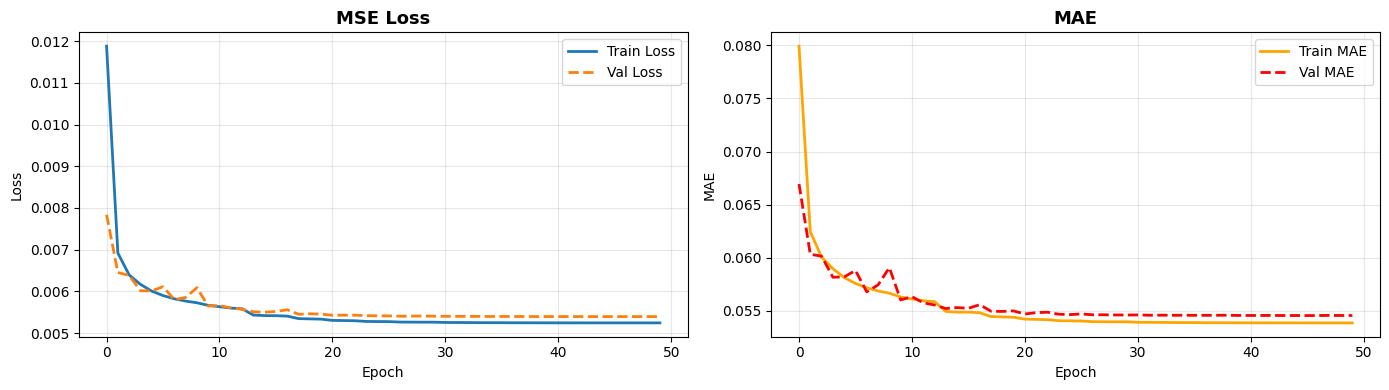

Best val_loss: 0.00539


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[0].set_title('MSE Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history.history['mae'],     label='Train MAE', linewidth=2, color='orange')
axes[1].plot(history.history['val_mae'], label='Val MAE',   linewidth=2, linestyle='--', color='red')
axes[1].set_title('MAE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Best val_loss: {min(history.history["val_loss"]):.5f}')

## 7. Evaluate: PSNR & SSIM

In [15]:
# Generate denoised predictions on test set
x_test_denoised = autoencoder.predict(x_test_noisy, batch_size=256, verbose=0)

def compute_metrics(clean, restored):
    psnr_scores, ssim_scores = [], []
    for c, r in zip(clean, restored):
        psnr_scores.append(psnr(c, r, data_range=1.0))
        ssim_scores.append(ssim(c, r, data_range=1.0, channel_axis=-1))
    return np.mean(psnr_scores), np.mean(ssim_scores)

psnr_noisy,    ssim_noisy    = compute_metrics(x_test, x_test_noisy)
psnr_denoised, ssim_denoised = compute_metrics(x_test, x_test_denoised)

print('─' * 45)
print(f'  Metric        Noisy       Denoised')
print('─' * 45)
print(f'  PSNR (dB)    {psnr_noisy:6.2f}      {psnr_denoised:6.2f}  (+{psnr_denoised - psnr_noisy:.2f})')
print(f'  SSIM         {ssim_noisy:.4f}      {ssim_denoised:.4f}  (+{ssim_denoised - ssim_noisy:.4f})')
print('─' * 45)

─────────────────────────────────────────────
  Metric        Noisy       Denoised
─────────────────────────────────────────────
  PSNR (dB)     11.93       22.92  (+10.99)
  SSIM         0.2939      0.7575  (+0.4636)
─────────────────────────────────────────────


## 8. Visual Comparison

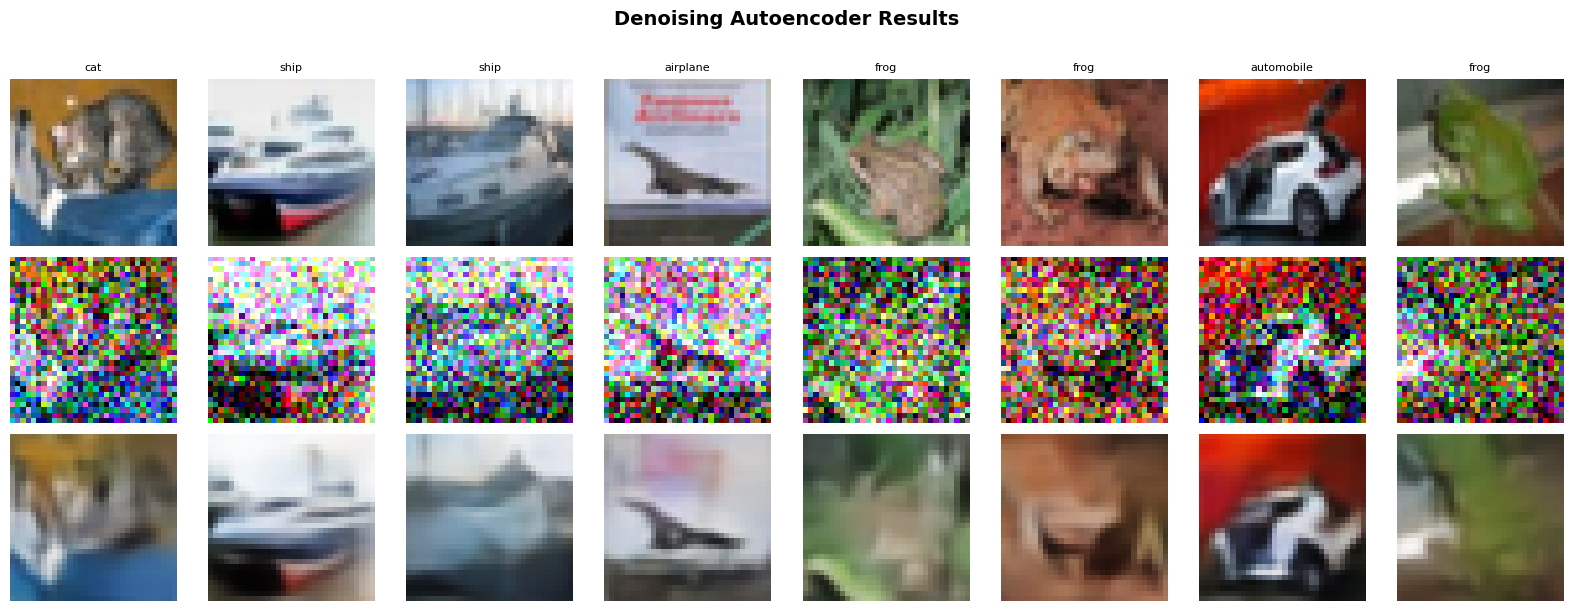

In [16]:
def show_results(clean, noisy, denoised, n=8, labels=None):
    fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
    row_labels = ['Original', 'Noisy', 'Denoised']
    images = [clean, noisy, denoised]

    for row, (row_imgs, row_label) in enumerate(zip(images, row_labels)):
        axes[row, 0].set_ylabel(row_label, fontsize=11, fontweight='bold')
        for col in range(n):
            axes[row, col].imshow(np.clip(row_imgs[col], 0, 1))
            axes[row, col].axis('off')
            if row == 0 and labels is not None:
                axes[row, col].set_title(class_names[labels[col][0]], fontsize=8)

    plt.suptitle('Denoising Autoencoder Results', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

show_results(x_test[:8], x_test_noisy[:8], x_test_denoised[:8], labels=y_test[:8])

## 9. Per-Class Analysis

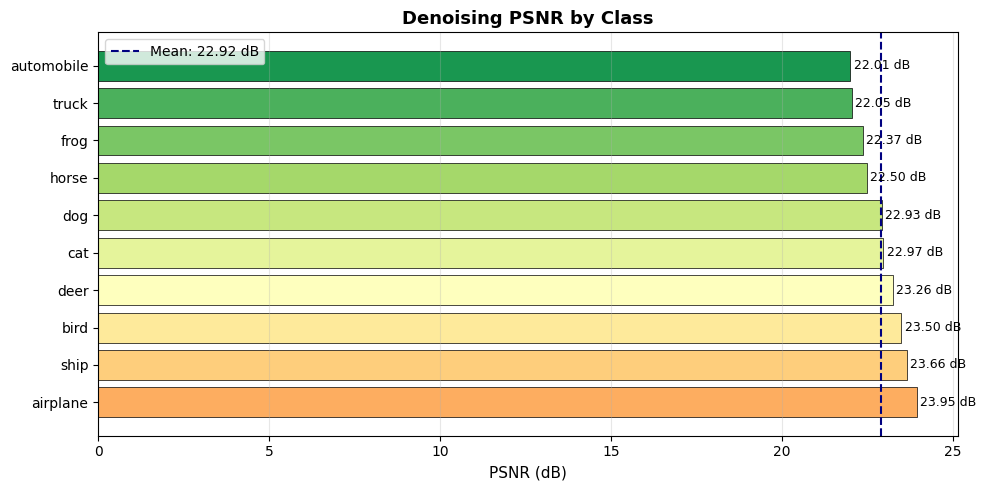

In [17]:
# Compute PSNR per class
class_psnr = {}
for cls_idx, cls_name in enumerate(class_names):
    mask = (y_test.flatten() == cls_idx)
    p, _ = compute_metrics(x_test[mask], x_test_denoised[mask])
    class_psnr[cls_name] = p

sorted_classes = sorted(class_psnr.items(), key=lambda x: x[1], reverse=True)
names, scores = zip(*sorted_classes)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(names)))
bars = ax.barh(names, scores, color=colors, edgecolor='black', linewidth=0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{score:.2f} dB', va='center', fontsize=9)

ax.axvline(psnr_denoised, color='navy', linestyle='--', linewidth=1.5, label=f'Mean: {psnr_denoised:.2f} dB')
ax.set_xlabel('PSNR (dB)', fontsize=11)
ax.set_title('Denoising PSNR by Class', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Test Different Noise Levels

Noise=0.1 | Input PSNR: 20.33 dB → Output PSNR: 23.33 dB | SSIM: 0.7707
Noise=0.2 | Input PSNR: 14.79 dB → Output PSNR: 23.63 dB | SSIM: 0.7830
Noise=0.3 | Input PSNR: 11.94 dB → Output PSNR: 22.93 dB | SSIM: 0.7578
Noise=0.4 | Input PSNR: 10.22 dB → Output PSNR: 20.82 dB | SSIM: 0.6730
Noise=0.5 | Input PSNR: 9.13 dB → Output PSNR: 18.77 dB | SSIM: 0.5732


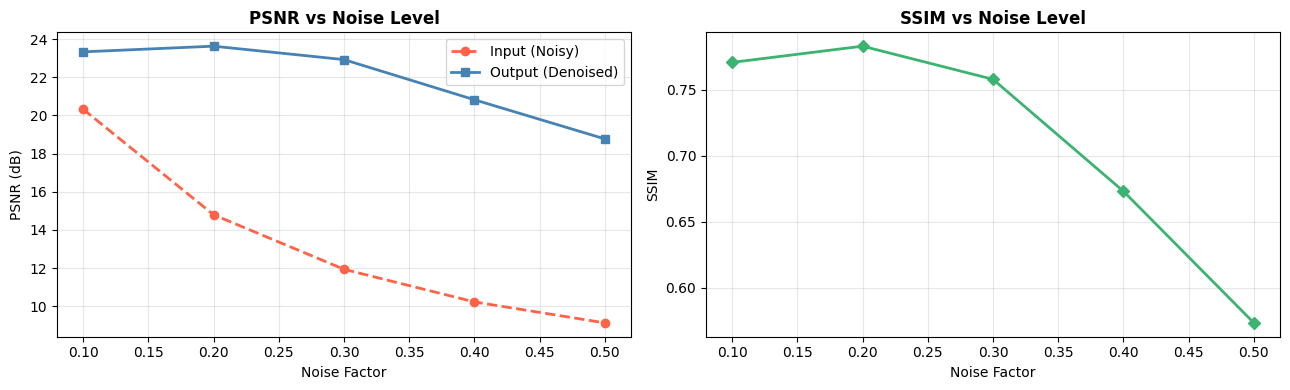

In [18]:
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []

for nf in noise_levels:
    noisy_imgs = add_noise(x_test, nf)
    denoised   = autoencoder.predict(noisy_imgs, batch_size=256, verbose=0)
    p, s = compute_metrics(x_test, denoised)
    p_noisy, _ = compute_metrics(x_test, noisy_imgs)
    results.append({'noise': nf, 'psnr_in': p_noisy, 'psnr_out': p, 'ssim': s})
    print(f'Noise={nf:.1f} | Input PSNR: {p_noisy:.2f} dB → Output PSNR: {p:.2f} dB | SSIM: {s:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
nf_vals = [r['noise'] for r in results]

axes[0].plot(nf_vals, [r['psnr_in']  for r in results], 'o--', label='Input (Noisy)',    color='tomato',    linewidth=2)
axes[0].plot(nf_vals, [r['psnr_out'] for r in results], 's-',  label='Output (Denoised)', color='steelblue', linewidth=2)
axes[0].set_xlabel('Noise Factor'); axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR vs Noise Level', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(nf_vals, [r['ssim'] for r in results], 'D-', color='mediumseagreen', linewidth=2)
axes[1].set_xlabel('Noise Factor'); axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM vs Noise Level', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Save & Download Model

In [19]:
# Save in Keras native format
autoencoder.save('cifar10_denoising_autoencoder.keras')
print('Model saved!')

# Download to local machine
from google.colab import files
files.download('cifar10_denoising_autoencoder.keras')

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. (Optional) Experiment: Deeper Architecture

Try this improved architecture with **Batch Normalization** and **residual-style connections** for better results.

In [20]:
def build_deeper_autoencoder(input_shape=(32, 32, 3)):
    def conv_bn_relu(x, filters, kernel=3):
        x = layers.Conv2D(filters, kernel, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return x

    inputs = keras.Input(shape=input_shape)

    # Encoder
    x = conv_bn_relu(inputs, 64)
    x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D(2)(x)            # 16×16
    x = conv_bn_relu(x, 128)
    x = conv_bn_relu(x, 128)
    x = layers.MaxPooling2D(2)(x)            # 8×8
    x = conv_bn_relu(x, 256)

    # Decoder
    x = layers.UpSampling2D(2)(x)            # 16×16
    x = conv_bn_relu(x, 128)
    x = conv_bn_relu(x, 64)
    x = layers.UpSampling2D(2)(x)            # 32×32
    x = conv_bn_relu(x, 64)
    outputs = layers.Conv2D(3, 1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name='Deeper_DAE')

deeper_model = build_deeper_autoencoder()
deeper_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
deeper_model.summary()

# Uncomment to train:
# history2 = deeper_model.fit(
#     x_train_noisy, x_train, epochs=50, batch_size=128,
#     validation_data=(x_test_noisy, x_test),
#     callbacks=callbacks
# )

Model: "Deeper_DAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 16, 16, 128)    │             

 Total params: 964,867 (3.68 MB)

 Trainable params: 963,075 (3.67 MB)

 Non-trainable params: 1,792 (7.00 KB)